# Проект: Детектирование медицинских масок

**Задача.** Обучить и сравнить **два детектора объектов** — двухуровневый (семейство R-CNN) и одноуровневый (семейство YOLO) — для распознавания трёх классов:

* `without_mask` — без маски,
* `with_mask` — в маске,
* `mask_weared_incorrect` — маска надета неправильно.

**Метрики.** Для каждой модели считаем **IoU** и **Average Precision (AP)**, строим **Precision–Recall кривые** и сравниваем **mean Average Precision (mAP@0.5)**.

**Цель.** Добиться **mAP@0.5 > 0.85** на валидационной выборке для каждой модели.

**Данные.** [Face Mask Detection (Kaggle)](https://www.kaggle.com/datasets/andrewmvd/face-mask-detection) — 853 изображения, аннотации в формате Pascal VOC (XML). Данные лежат в `data/images/` и `data/annotations/`.

# 1. Импорт библиотек

In [1]:
# based on https://www.kaggle.com/konstanter/fasterrcnn-pytorch-maskdetection

import os
import glob
import xml.etree.ElementTree as et

import numpy as np
import pandas as pd
import cv2
from PIL import Image
import matplotlib.pyplot as plt
import matplotlib.patches as patches

import torch
import torchvision
from torchvision import transforms, datasets, models
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor

import albumentations as A
from albumentations.pytorch.transforms import ToTensorV2

# torchmetrics нужен для перекрёстной проверки mAP (надёжная эталонная реализация)
try:
    from torchmetrics.detection import MeanAveragePrecision
except ImportError:
    import sys
    !{sys.executable} -m pip install -q torchmetrics
    from torchmetrics.detection import MeanAveragePrecision

print('torch:', torch.__version__)
print('torchvision:', torchvision.__version__)
print('CUDA доступна:', torch.cuda.is_available())

torch: 2.5.1+cu121
torchvision: 0.20.1+cu121
CUDA доступна: True


# 2. Загрузка данных в DataLoader

Класс `FaceMaskDataset` читает изображение и соответствующий XML-файл аннотации, масштабирует картинку и боксы к фиксированному размеру и возвращает `(image, target)` в формате, который ожидает `torchvision`-детектор.

In [2]:
# путь к файлам
images_dir = 'data/images/'
annotations_dir = 'data/annotations/'

# на сколько занижаем верхние границы bbox, чтобы они гарантированно
# лежали внутри изображения (иначе новые версии Albumentations отвергают
# координаты вида width+1, дающие после нормализации значения > 1.0)
_BBOX_EPS = 1.0


class FaceMaskDataset(torch.utils.data.Dataset):

    def __init__(self, images_dir, annotation_dir, width, height, transforms=None):
        self.transforms = transforms
        self.images_dir = images_dir
        self.annotation_dir = annotation_dir
        self.height = height
        self.width = width

        # сортируем, чтобы изображение и его аннотация были на одинаковых позициях
        self.imgs = [image for image in sorted(os.listdir(images_dir))]
        self.annotate = [image for image in sorted(os.listdir(annotation_dir))]

        # класс 0 зарезервирован под фон (требование Faster R-CNN)
        self.classes = ['_background_', 'without_mask', 'with_mask', 'mask_weared_incorrect']

    def __getitem__(self, idx):
        img_name = self.imgs[idx]
        image_path = os.path.join(self.images_dir, img_name)

        # читаем картинку, переводим BGR->RGB, масштабируем, нормализуем в [0,1]
        img = cv2.imread(image_path)
        img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB).astype(np.float32)
        img_res = cv2.resize(img_rgb, (self.width, self.height), cv2.INTER_AREA)
        img_res /= 255.0

        annot_filename = self.annotate[idx]
        annot_file_path = os.path.join(self.annotation_dir, annot_filename)

        boxes = []
        labels = []
        tree = et.parse(annot_file_path)
        root = tree.getroot()

        wt = img.shape[1]   # исходная ширина
        ht = img.shape[0]   # исходная высота

        max_x = float(self.width) - _BBOX_EPS
        max_y = float(self.height) - _BBOX_EPS

        for member in root.findall('object'):
            label_idx = self.classes.index(member.find('name').text)

            xmin = int(member.find('bndbox').find('xmin').text)
            xmax = int(member.find('bndbox').find('xmax').text)
            ymin = int(member.find('bndbox').find('ymin').text)
            ymax = int(member.find('bndbox').find('ymax').text)

            # пересчёт координат под новый размер изображения
            xmin_corr = (xmin / wt) * self.width
            xmax_corr = (xmax / wt) * self.width
            ymin_corr = (ymin / ht) * self.height
            ymax_corr = (ymax / ht) * self.height

            # жёсткий clip: гарантируем 0 <= coord < width/height и xmax>xmin
            xmin_corr = float(np.clip(xmin_corr, 0.0, max_x - _BBOX_EPS))
            ymin_corr = float(np.clip(ymin_corr, 0.0, max_y - _BBOX_EPS))
            xmax_corr = float(np.clip(xmax_corr, xmin_corr + _BBOX_EPS, max_x))
            ymax_corr = float(np.clip(ymax_corr, ymin_corr + _BBOX_EPS, max_y))

            if xmax_corr <= xmin_corr or ymax_corr <= ymin_corr:
                continue  # пропускаем вырожденные боксы

            boxes.append([xmin_corr, ymin_corr, xmax_corr, ymax_corr])
            labels.append(label_idx)

        # аугментации (bboxes и labels — обычные списки, иначе Albumentations падает)
        if self.transforms:
            sample = self.transforms(image=img_res, bboxes=boxes, labels=labels)
            img_res = sample['image']
            boxes = sample['bboxes']
            labels = sample['labels']

        # сборка target — все значения должны быть тензорами нужного типа
        if len(boxes) == 0:
            boxes_t = torch.zeros((0, 4), dtype=torch.float32)
            labels_t = torch.zeros((0,), dtype=torch.int64)
            area = torch.zeros((0,), dtype=torch.float32)
        else:
            boxes_t = torch.as_tensor(boxes, dtype=torch.float32)
            labels_t = torch.as_tensor(labels, dtype=torch.int64)
            area = (boxes_t[:, 3] - boxes_t[:, 1]) * (boxes_t[:, 2] - boxes_t[:, 0])

        iscrowd = torch.zeros((boxes_t.shape[0],), dtype=torch.int64)
        image_id = torch.tensor([idx])

        target = {
            "boxes": boxes_t,
            "labels": labels_t,
            "area": area,
            "iscrowd": iscrowd,
            "image_id": image_id,
        }
        return img_res, target

    def __len__(self):
        return len(self.imgs)


# быстрая проверка
dataset = FaceMaskDataset(images_dir, annotations_dir, 224, 224)
print('Размер датасета =', len(dataset))
img, target = dataset[78]
print('Image shape =', img.shape)
print('Target =', target)

Размер датасета = 853
Image shape = (224, 224, 3)
Target = {'boxes': tensor([[113.1163, 146.7200, 163.7209, 205.5200]]), 'labels': tensor([2]), 'area': tensor([2975.5537]), 'iscrowd': tensor([0]), 'image_id': tensor([78])}


>>> plot_img_bbox v5 загружен


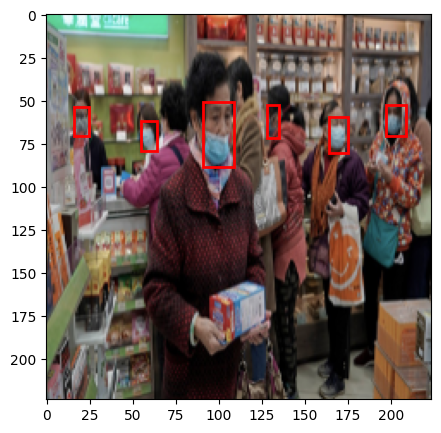

In [3]:
# Вспомогательная функция для визуализации bbox на изображении

def plot_img_bbox(img, target):
    # если img — тензор, переносим на CPU и приводим к [H, W, C]
    if torch.is_tensor(img):
        img = img.detach().cpu()
        if img.dim() == 3 and img.shape[0] in (1, 3):
            img = img.permute(1, 2, 0)
        img = img.numpy()

    fig, a = plt.subplots(1, 1)
    fig.set_size_inches(5, 5)
    a.imshow(img)

    boxes = target['boxes']
    if torch.is_tensor(boxes):
        boxes = boxes.detach().cpu().numpy()

    for box in boxes:
        x, y = float(box[0]), float(box[1])
        width = float(box[2]) - float(box[0])
        height = float(box[3]) - float(box[1])
        rect = patches.Rectangle((x, y), width, height,
                                 linewidth=2, edgecolor='r', facecolor='none')
        a.add_patch(rect)
    plt.show()
    
print(">>> plot_img_bbox v5 загружен")

img, target = dataset[35]
plot_img_bbox(img, target)

In [4]:
def get_transform(train):
    # Усиленные аугментации помогают редкому классу mask_weared_incorrect:
    # модель видит больше вариаций тех немногих примеров, что есть.
    if train:
        return A.Compose([
            A.HorizontalFlip(p=0.5),
            A.RandomBrightnessContrast(brightness_limit=0.2, contrast_limit=0.2, p=0.3),
            A.HueSaturationValue(hue_shift_limit=10, sat_shift_limit=20,
                                 val_shift_limit=10, p=0.3),
            A.ShiftScaleRotate(shift_limit=0.05, scale_limit=0.1,
                               rotate_limit=10, border_mode=0, p=0.3),
            ToTensorV2(p=1.0),
        ], bbox_params=A.BboxParams(format='pascal_voc',
                                    label_fields=['labels'],
                                    min_visibility=0.3,
                                    clip=True))
    else:
        return A.Compose([
            ToTensorV2(p=1.0),
        ], bbox_params=A.BboxParams(format='pascal_voc',
                                    label_fields=['labels'],
                                    min_visibility=0.0,
                                    clip=True))

In [5]:
def collate_fn(batch):
    # детекторы принимают батч переменной длины -> упаковываем в кортеж
    return tuple(zip(*batch))

In [6]:
# Размер изображения для Faster R-CNN.
# 800px (вместо 480) критично: лица в толпе мелкие, при 480 теряются —
# это и роняло AP редких/мелких объектов. RTX 4070 Ti (12 ГБ) тянет.
IMG_SIZE = 800

dataset = FaceMaskDataset(images_dir, annotations_dir, IMG_SIZE, IMG_SIZE,
                          transforms=get_transform(train=True))
dataset_test = FaceMaskDataset(images_dir, annotations_dir, IMG_SIZE, IMG_SIZE,
                               transforms=get_transform(train=False))

# фиксируем seed и делим на train / val (80/20).
# ЭТОТ ЖЕ split используем потом для YOLO -> честное сравнение моделей
torch.manual_seed(1)
indices = torch.randperm(len(dataset)).tolist()

test_split = 0.2
tsize = int(len(dataset) * test_split)
train_indices = indices[:-tsize]
val_indices = indices[-tsize:]

dataset = torch.utils.data.Subset(dataset, train_indices)
dataset_test = torch.utils.data.Subset(dataset_test, val_indices)

# batch_size=2 при 800px, чтобы уместиться в 12 ГБ VRAM
data_loader = torch.utils.data.DataLoader(
    dataset, batch_size=2, shuffle=True, num_workers=0, collate_fn=collate_fn)

data_loader_test = torch.utils.data.DataLoader(
    dataset_test, batch_size=2, shuffle=False, num_workers=0, collate_fn=collate_fn)

print('train:', len(dataset), ' val:', len(dataset_test))

train: 683  val: 170


c:\Users\Олег\AppData\Local\Programs\Python\Python311\Lib\site-packages\albumentations\core\validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)
c:\Users\Олег\AppData\Local\Programs\Python\Python311\Lib\site-packages\albumentations\core\composition.py:331: UserWarning: Got processor for bboxes, but no transform to process it.
  self._set_keys()


## 2.1 Отрисовка одного батча загруженных данных

Критерий: *«Отрисовать один батч загруженных данных»*. Берём первый батч из `data_loader` и рисуем изображения вместе с истинными рамками.

Изображений в батче: 2 | форма картинки: torch.Size([3, 800, 800])


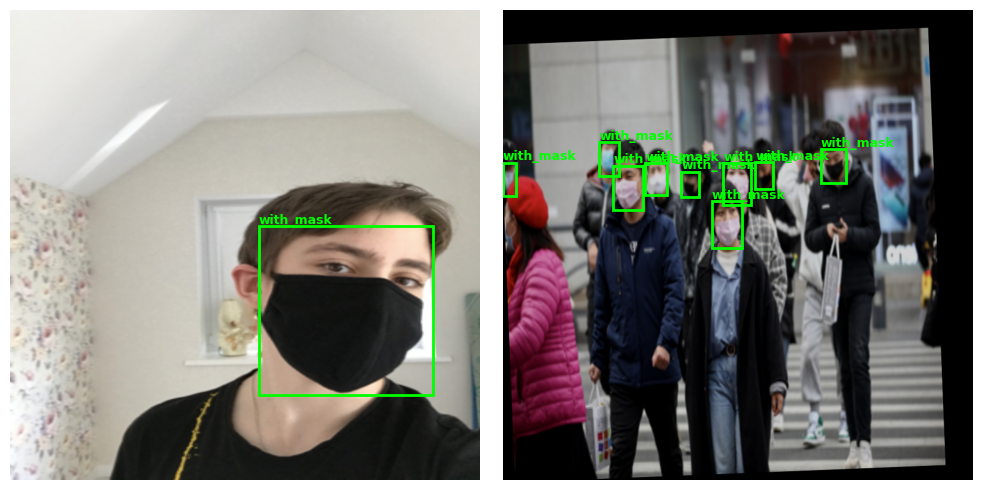

In [7]:
# цвета и названия классов для отрисовки
CLASS_NAMES = ['_background_', 'without_mask', 'with_mask', 'mask_weared_incorrect']
CLASS_COLORS = {1: 'red', 2: 'lime', 3: 'yellow'}


def draw_batch(imgs, targets, n=4):
    n = min(n, len(imgs))
    fig, axes = plt.subplots(1, n, figsize=(5 * n, 5))
    if n == 1:
        axes = [axes]
    for ax, img, tgt in zip(axes, imgs[:n], targets[:n]):
        im = img.detach().cpu().permute(1, 2, 0).numpy()
        ax.imshow(im)
        boxes = tgt['boxes'].cpu().numpy()
        labels = tgt['labels'].cpu().numpy()
        for box, lab in zip(boxes, labels):
            x, y = box[0], box[1]
            w, h = box[2] - box[0], box[3] - box[1]
            color = CLASS_COLORS.get(int(lab), 'white')
            ax.add_patch(patches.Rectangle((x, y), w, h, linewidth=2,
                                           edgecolor=color, facecolor='none'))
            ax.text(x, y - 4, CLASS_NAMES[int(lab)], color=color, fontsize=9,
                    weight='bold')
        ax.axis('off')
    plt.tight_layout()
    plt.show()


# берём один батч и рисуем
imgs_b, targets_b = next(iter(data_loader))
print('Изображений в батче:', len(imgs_b), '| форма картинки:', imgs_b[0].shape)
draw_batch(imgs_b, targets_b, n=4)

# 3. Выбор предобученных моделей и обоснование

Критерий: *«Используется предобученная модель и её выбор обоснован в комментариях»*.

Задача требует **сравнить два семейства детекторов**, поэтому берём по одному представителю каждого подхода — оба **предобученные на COCO** (перенос обучения, transfer learning):

### Модель 1 — Faster R-CNN (ResNet-50 + FPN). Двухуровневый детектор (семейство R-CNN)
* **Как работает.** Сначала Region Proposal Network предлагает кандидатов-регионы, затем второй этап их классифицирует и уточняет рамки. Два этапа дают **высокую точность локализации**, что важно для мелких объектов — лиц/масок в толпе.
* **Feature Pyramid Network** строит признаки на нескольких масштабах → хорошо ловит и крупные, и мелкие лица.
* **Предобучение на COCO** даёт сильный backbone; нам остаётся дообучить «голову» на 3 наших класса (заменяем `box_predictor`). Это и есть перенос обучения — он позволяет достичь высокого качества на маленьком датасете (853 изображения).
* **Минус:** медленнее на инференсе, чем одноуровневые.

### Модель 2 — YOLOv8s. Одноуровневый детектор (семейство YOLO)
* **Как работает.** Предсказывает классы и рамки за **один проход** сети по всей картинке — отсюда высокая скорость, пригодная для real-time видео.
* **Предобучение на COCO** + сильные встроенные аугментации (mosaic, mixup, HSV) → быстро достигает высокого mAP даже на небольших данных.
* **Минус:** исторически чуть хуже на очень мелких/плотно расположенных объектах, чем двухуровневые (хотя v8 этот разрыв почти закрыл).

### Почему именно эта пара
Это классическое противопоставление **«точность vs скорость»**, которое и просит задание (одноуровневый против двухуровневого). Обе модели используют перенос обучения с COCO, что критично при 853 изображениях. Сравним их по единой метрике **mAP@0.5** на **одной и той же** валидационной выборке.

# 4. Модель 1 — Faster R-CNN (двухуровневый)

## 4.1 Создание модели с переносом обучения

In [8]:
def get_model_instance_detection(num_classes):
    # берём Faster R-CNN, предобученный на COCO
    model = torchvision.models.detection.fasterrcnn_resnet50_fpn(weights="DEFAULT")

    # заменяем классификатор-голову под наше число классов (3 + фон = 4)
    in_features = model.roi_heads.box_predictor.cls_score.in_features
    model.roi_heads.box_predictor = FastRCNNPredictor(in_features, num_classes)
    return model

## 4.2 Обучение на обучающей выборке

In [9]:
device = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')
print('device:', device)

num_classes = 4  # 3 класса + фон
model = get_model_instance_detection(num_classes).to(device)

# 30 эпох (было 15) — больше шагов для сходимости по редкому классу
num_epochs = 30

params = [p for p in model.parameters() if p.requires_grad]
optimizer = torch.optim.SGD(params, lr=0.005, momentum=0.9, weight_decay=0.0005)

# warmup + косинусное затухание LR: стабильнее, чем резкий StepLR.
# Плавное снижение помогает дообучить редкий класс к концу обучения.
warmup_epochs = 1
def lr_lambda(epoch):
    if epoch < warmup_epochs:
        return (epoch + 1) / warmup_epochs
    progress = (epoch - warmup_epochs) / max(1, num_epochs - warmup_epochs)
    return 0.5 * (1 + np.cos(np.pi * progress))  # cosine 1->0
lr_scheduler = torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)

for epoch in range(num_epochs):
    model.train()
    epoch_loss = 0.0
    for imgs, annotations in data_loader:
        imgs = [img.to(device) for img in imgs]
        annotations = [{k: v.to(device) for k, v in t.items()} for t in annotations]

        loss_dict = model(imgs, annotations)      # на train модель возвращает лоссы
        losses = sum(loss for loss in loss_dict.values())

        optimizer.zero_grad()
        losses.backward()
        optimizer.step()
        epoch_loss += losses.item()

    lr_scheduler.step()
    print(f'Epoch {epoch + 1}/{num_epochs}  loss = {epoch_loss:.4f}  lr = {optimizer.param_groups[0]["lr"]:.5f}')

# сохраняем веса, чтобы не переобучать заново
torch.save(model.state_dict(), 'fasterrcnn_mask.pth')
print('Веса сохранены в fasterrcnn_mask.pth')

device: cuda
Epoch 1/30  loss = 141.0481  lr = 0.00500
Epoch 2/30  loss = 108.3067  lr = 0.00499
Epoch 3/30  loss = 98.7800  lr = 0.00494
Epoch 4/30  loss = 92.7528  lr = 0.00487
Epoch 5/30  loss = 87.6233  lr = 0.00477
Epoch 6/30  loss = 81.7617  lr = 0.00464
Epoch 7/30  loss = 79.8486  lr = 0.00449
Epoch 8/30  loss = 76.2121  lr = 0.00431
Epoch 9/30  loss = 73.2293  lr = 0.00412
Epoch 10/30  loss = 69.4558  lr = 0.00390
Epoch 11/30  loss = 68.6693  lr = 0.00367
Epoch 12/30  loss = 67.5588  lr = 0.00343
Epoch 13/30  loss = 62.7729  lr = 0.00317
Epoch 14/30  loss = 62.0612  lr = 0.00290
Epoch 15/30  loss = 58.8095  lr = 0.00264
Epoch 16/30  loss = 57.6561  lr = 0.00236
Epoch 17/30  loss = 56.5244  lr = 0.00210
Epoch 18/30  loss = 54.0471  lr = 0.00183
Epoch 19/30  loss = 52.0429  lr = 0.00157
Epoch 20/30  loss = 48.0506  lr = 0.00133
Epoch 21/30  loss = 47.1315  lr = 0.00110
Epoch 22/30  loss = 47.3268  lr = 0.00088
Epoch 23/30  loss = 44.8829  lr = 0.00069
Epoch 24/30  loss = 46.6566 

## 4.3 Вспомогательные функции инференса

In [10]:
def apply_nms(orig_prediction, iou_thresh=0.3):
    # Non-Maximum Suppression: убираем перекрывающиеся дубли рамок
    keep = torchvision.ops.nms(orig_prediction['boxes'],
                               orig_prediction['scores'], iou_thresh)
    return {
        'boxes': orig_prediction['boxes'][keep],
        'scores': orig_prediction['scores'][keep],
        'labels': orig_prediction['labels'][keep],
    }


def torch_to_pil(img):
    if torch.is_tensor(img):
        img = img.detach().cpu()
    return transforms.ToPILImage()(img).convert('RGB')

## 4.4 Визуализация предсказаний модели

In [11]:
def plot_image(img_tensor, annotation, predict=True):
    fig, ax = plt.subplots(1)
    fig.set_size_inches(11, 8)
    img = img_tensor.detach().cpu()
    mask_dic = {1: 'without_mask', 2: 'with_mask', 3: 'mask_weared_incorrect'}

    ax.imshow(img.permute(1, 2, 0))

    boxes = annotation['boxes'].detach().cpu()
    labels_t = annotation['labels'].detach().cpu()
    scores_t = annotation['scores'].detach().cpu() if 'scores' in annotation else None

    for i, box in enumerate(boxes):
        xmin, ymin, xmax, ymax = box.tolist()
        color = CLASS_COLORS.get(int(labels_t[i]), 'white')
        ax.add_patch(patches.Rectangle((xmin, ymin), xmax - xmin, ymax - ymin,
                                       linewidth=2, edgecolor=color, facecolor='none'))
        label = mask_dic[int(labels_t[i])]
        if predict and scores_t is not None:
            score = int(float(scores_t[i]) * 100)
            ax.text(xmin, ymin - 4, f"{label}:{score}%", color=color,
                    fontsize=11, weight='bold')
        else:
            ax.text(xmin, ymin - 4, label, color=color, fontsize=11, weight='bold')
    ax.axis('off')
    plt.show()

In [12]:
# один пример: эталон vs предсказание
img, target = dataset_test[4]

model.eval()
with torch.no_grad():
    prediction = model([img.to(device)])[0]
prediction = {k: v.detach().cpu() for k, v in prediction.items()}  # на CPU для отрисовки

print('Предсказано рамок:', len(prediction['labels']),
      '| Истинных рамок:', len(target['labels']))

nms_pred = apply_nms(prediction, iou_thresh=0.2)
print('После NMS:', len(nms_pred['labels']))

Предсказано рамок: 1 | Истинных рамок: 1
После NMS: 1


In [13]:
# берём один батч из валидации для наглядного сравнения
for imgs_v, annots_v in data_loader_test:
    imgs_v = [im.to(device) for im in imgs_v]
    break

model.eval()
with torch.no_grad():
    preds_v = model(imgs_v)
preds_v = [{k: v.detach().cpu() for k, v in p.items()} for p in preds_v]

Предсказание модели Faster R-CNN


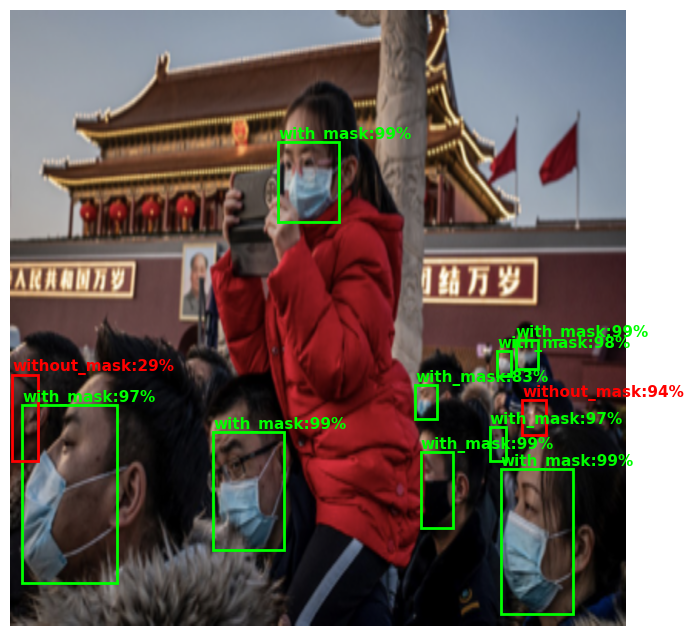

Истинная разметка


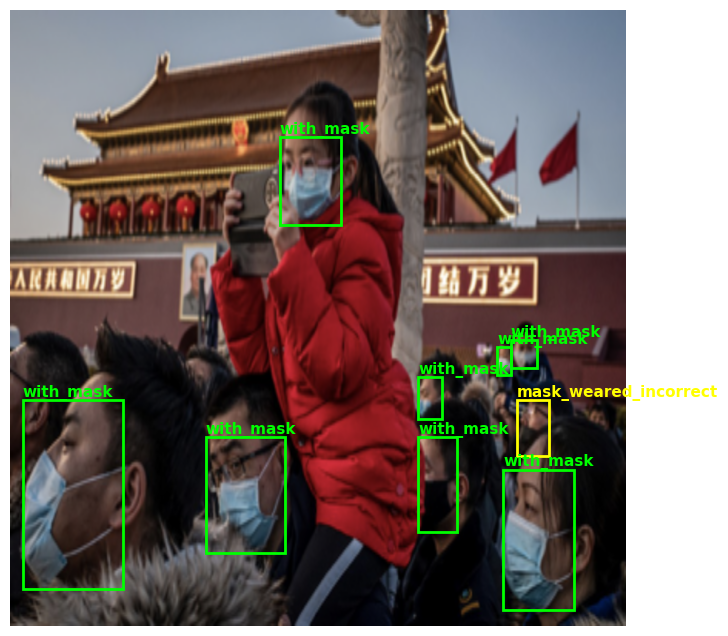

In [14]:
nms_prediction = apply_nms(preds_v[0], iou_thresh=0.2)
print("Предсказание модели Faster R-CNN")
plot_image(imgs_v[0].cpu(), nms_prediction, predict=True)
print("Истинная разметка")
plot_image(imgs_v[0].cpu(), annots_v[0], predict=False)

Предсказание модели Faster R-CNN


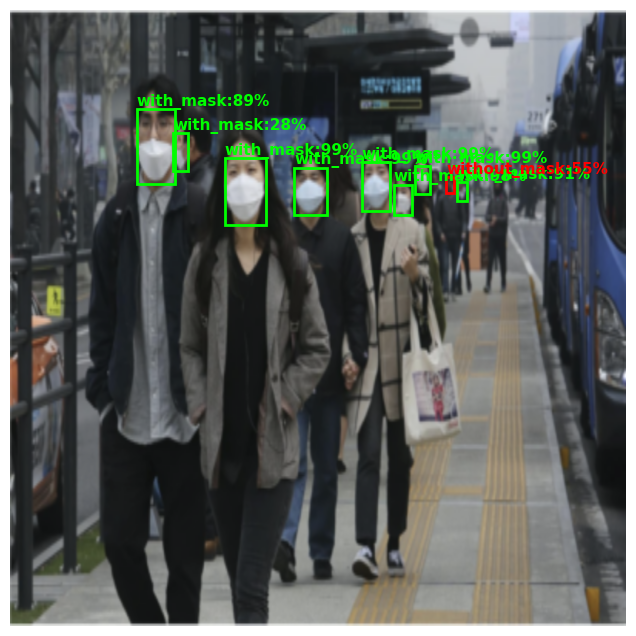

Истинная разметка


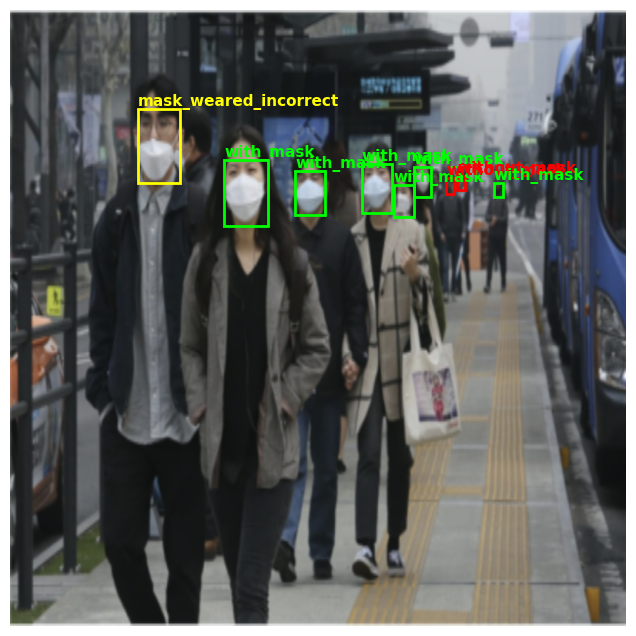

In [15]:
nms_prediction = apply_nms(preds_v[1], iou_thresh=0.2)
print("Предсказание модели Faster R-CNN")
plot_image(imgs_v[1].cpu(), nms_prediction, predict=True)
print("Истинная разметка")
plot_image(imgs_v[1].cpu(), annots_v[1], predict=False)

# 5. Метрики: IoU, Average Precision и Precision–Recall кривые

Критерий: *«Посчитать метрики IoU и AP для каждой модели и построить графики Precision-Recall»*.

Ниже — собственная реализация метрик (чтобы был виден сам алгоритм), а в конце — перекрёстная проверка эталонной библиотекой `torchmetrics`.

**Краткая теория.**
* **IoU (Intersection over Union)** — отношение площади пересечения предсказанной и истинной рамок к площади их объединения. Предсказание считается верным (True Positive), если IoU с истинной рамкой того же класса ≥ порога (берём **0.5**).
* **Average Precision (AP)** — площадь под кривой Precision–Recall для класса. Детекции сортируются по уверенности (score), накапливаются TP/FP, считаются precision и recall, AP = площадь под кривой.
* **mAP** — среднее AP по всем классам.

In [17]:
def box_iou_matrix(boxes1, boxes2):
    """IoU между наборами рамок. boxes: numpy [N,4] и [M,4] -> матрица [N,M].
    Формат рамки: [xmin, ymin, xmax, ymax]."""
    if len(boxes1) == 0 or len(boxes2) == 0:
        return np.zeros((len(boxes1), len(boxes2)), dtype=np.float32)

    x11, y11, x12, y12 = np.split(boxes1, 4, axis=1)
    x21, y21, x22, y22 = np.split(boxes2, 4, axis=1)

    # координаты пересечения
    xA = np.maximum(x11, x21.T)
    yA = np.maximum(y11, y21.T)
    xB = np.minimum(x12, x22.T)
    yB = np.minimum(y12, y22.T)

    inter = np.clip(xB - xA, 0, None) * np.clip(yB - yA, 0, None)
    area1 = (x12 - x11) * (y12 - y11)
    area2 = (x22 - x21) * (y22 - y21)
    union = area1 + area2.T - inter
    return inter / np.clip(union, 1e-9, None)


# демонстрация работы IoU на двух рамках
b1 = np.array([[10, 10, 50, 50]], dtype=np.float32)
b2 = np.array([[30, 30, 70, 70]], dtype=np.float32)
print('Пример IoU двух рамок:', round(float(box_iou_matrix(b1, b2)[0, 0]), 4))

Пример IoU двух рамок: 0.1429


In [18]:
def voc_ap(recall, precision):
    """AP как площадь под PR-кривой (интерполяция по всем точкам, VOC2010+)."""
    mrec = np.concatenate(([0.0], recall, [1.0]))
    mpre = np.concatenate(([0.0], precision, [0.0]))
    # делаем precision монотонно невозрастающей справа налево
    for i in range(mpre.size - 1, 0, -1):
        mpre[i - 1] = np.maximum(mpre[i - 1], mpre[i])
    # суммируем площадь там, где меняется recall
    idx = np.where(mrec[1:] != mrec[:-1])[0]
    ap = np.sum((mrec[idx + 1] - mrec[idx]) * mpre[idx + 1])
    return ap, mrec, mpre


def evaluate_detections(preds, gts, class_ids, iou_thresh=0.5):
    """preds/gts — списки по изображениям.
    preds[i] = {boxes, scores, labels} (numpy), gts[i] = {boxes, labels} (numpy).
    Возвращает словарь class_id -> {ap, recall, precision, n_gt}."""
    results = {}
    for c in class_ids:
        detections = []          # (img_idx, score, box) по всем изображениям
        gt_boxes_per_img = []    # истинные рамки класса c для каждого изображения
        gt_used = []             # отметки «эта истинная рамка уже сматчена»
        n_gt = 0

        for i in range(len(gts)):
            gmask = gts[i]['labels'] == c
            gb = gts[i]['boxes'][gmask]
            gt_boxes_per_img.append(gb)
            gt_used.append(np.zeros(len(gb), dtype=bool))
            n_gt += len(gb)

            pmask = preds[i]['labels'] == c
            for box, score in zip(preds[i]['boxes'][pmask], preds[i]['scores'][pmask]):
                detections.append((i, float(score), box))

        if n_gt == 0:
            results[c] = dict(ap=float('nan'), recall=np.array([]),
                              precision=np.array([]), n_gt=0)
            continue

        # сортируем все детекции класса по убыванию уверенности
        detections.sort(key=lambda x: -x[1])
        tp = np.zeros(len(detections))
        fp = np.zeros(len(detections))

        for d, (img_idx, score, box) in enumerate(detections):
            gb = gt_boxes_per_img[img_idx]
            if len(gb) == 0:
                fp[d] = 1
                continue
            ious = box_iou_matrix(box[None, :], gb)[0]
            best = int(np.argmax(ious))
            if ious[best] >= iou_thresh and not gt_used[img_idx][best]:
                tp[d] = 1
                gt_used[img_idx][best] = True   # одна истинная рамка = один TP
            else:
                fp[d] = 1

        tp_cum = np.cumsum(tp)
        fp_cum = np.cumsum(fp)
        recall = tp_cum / n_gt
        precision = tp_cum / np.clip(tp_cum + fp_cum, 1e-9, None)
        ap, _, _ = voc_ap(recall, precision)
        results[c] = dict(ap=ap, recall=recall, precision=precision, n_gt=n_gt)
    return results

In [19]:
@torch.no_grad()
def collect_predictions(model, loader, device, score_thresh=0.01, nms_thresh=0.5):
    """Прогоняет модель по всей выборке и собирает предсказания и истину
    в numpy-формате для метрик.
    score_thresh низкий (0.01) — для метрики AP важен recall: чем больше
    кандидатов, тем полнее строится PR-кривая. nms_thresh=0.5 мягче режет."""
    model.eval()
    preds, gts = [], []
    for imgs, annots in loader:
        imgs_d = [im.to(device) for im in imgs]
        outputs = model(imgs_d)
        for out, ann in zip(outputs, annots):
            out = {k: v.detach().cpu() for k, v in out.items()}
            keep = torchvision.ops.nms(out['boxes'], out['scores'], nms_thresh)
            boxes = out['boxes'][keep].numpy()
            scores = out['scores'][keep].numpy()
            labels = out['labels'][keep].numpy()
            m = scores >= score_thresh
            preds.append(dict(boxes=boxes[m], scores=scores[m], labels=labels[m]))
            gts.append(dict(boxes=ann['boxes'].numpy(), labels=ann['labels'].numpy()))
    return preds, gts


# собираем предсказания на валидации и считаем метрики
frcnn_preds, frcnn_gts = collect_predictions(model, data_loader_test, device)

CLASS_IDS = [1, 2, 3]   # without_mask, with_mask, mask_weared_incorrect
frcnn_results = evaluate_detections(frcnn_preds, frcnn_gts, CLASS_IDS, iou_thresh=0.5)

print('=== Faster R-CNN: AP@0.5 по классам ===')
aps = []
for c in CLASS_IDS:
    ap = frcnn_results[c]['ap']
    aps.append(ap)
    print(f"  {CLASS_NAMES[c]:24s}  AP = {ap:.4f}  (объектов: {frcnn_results[c]['n_gt']})")

frcnn_map = float(np.nanmean(aps))
print(f"\n  mAP@0.5 = {frcnn_map:.4f}")

=== Faster R-CNN: AP@0.5 по классам ===
  without_mask              AP = 0.7810  (объектов: 212)
  with_mask                 AP = 0.9086  (объектов: 828)
  mask_weared_incorrect     AP = 0.4118  (объектов: 34)

  mAP@0.5 = 0.7005


## 5.1 Precision–Recall кривые (Faster R-CNN)

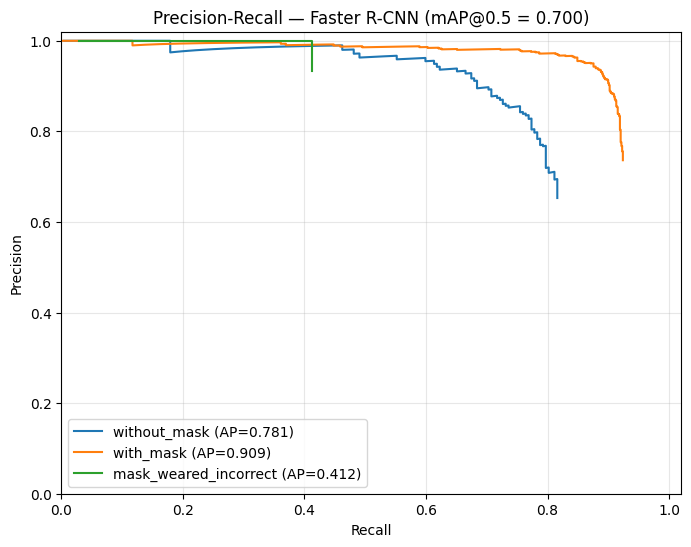

In [20]:
def plot_pr_curves(results, class_ids, title):
    plt.figure(figsize=(8, 6))
    for c in class_ids:
        r = results[c]
        if len(r['recall']) == 0:
            continue
        plt.plot(r['recall'], r['precision'],
                 label=f"{CLASS_NAMES[c]} (AP={r['ap']:.3f})")
    plt.xlabel('Recall')
    plt.ylabel('Precision')
    plt.title(title)
    plt.xlim(0, 1.02); plt.ylim(0, 1.02)
    plt.legend(); plt.grid(alpha=0.3)
    plt.show()


plot_pr_curves(frcnn_results, CLASS_IDS,
               f'Precision-Recall — Faster R-CNN (mAP@0.5 = {frcnn_map:.3f})')

# 6. Модель 2 — YOLOv8 (одноуровневый)

YOLO обучается через библиотеку `ultralytics` и требует данные в **своём формате**: на каждое изображение — `.txt` файл со строками `class_id x_center y_center width height` (координаты нормированы в [0, 1]).

## 6.1 Установка ultralytics

In [21]:
import sys
try:
    import ultralytics
except ImportError:
    !{sys.executable} -m pip install -q ultralytics
    import ultralytics
from ultralytics import YOLO
ultralytics.checks()

Ultralytics 8.4.51  Python-3.11.7 torch-2.5.1+cu121 CUDA:0 (NVIDIA GeForce RTX 4070 Ti, 12282MiB)
Setup complete  (12 CPUs, 63.9 GB RAM, 856.9/931.5 GB disk)


## 6.2 Конвертация Pascal VOC → YOLO (тот же train/val split)

In [22]:
import shutil
from pathlib import Path
import yaml

YOLO_ROOT = Path('yolo_data')
for sub in ['images/train', 'images/val', 'labels/train', 'labels/val']:
    (YOLO_ROOT / sub).mkdir(parents=True, exist_ok=True)

# списки файлов в том же порядке, что и в FaceMaskDataset
all_imgs = sorted(os.listdir(images_dir))
all_anns = sorted(os.listdir(annotations_dir))

# ВАЖНО: воспроизводим ТОТ ЖЕ split, что для Faster R-CNN (seed=1),
# чтобы сравнение моделей было честным — одинаковая валидация
torch.manual_seed(1)
_indices = torch.randperm(len(all_imgs)).tolist()
_tsize = int(len(all_imgs) * 0.2)
val_idx_set = set(_indices[-_tsize:])

# YOLO использует 0-индексацию классов (без фона)
yolo_cls_map = {'without_mask': 0, 'with_mask': 1, 'mask_weared_incorrect': 2}


def convert_one(img_file, ann_file, split):
    img_path = os.path.join(images_dir, img_file)
    im = cv2.imread(img_path)
    H, W = im.shape[:2]

    root = et.parse(os.path.join(annotations_dir, ann_file)).getroot()
    lines = []
    for m in root.findall('object'):
        name = m.find('name').text
        if name not in yolo_cls_map:
            continue
        c = yolo_cls_map[name]
        b = m.find('bndbox')
        xmin = float(b.find('xmin').text); xmax = float(b.find('xmax').text)
        ymin = float(b.find('ymin').text); ymax = float(b.find('ymax').text)
        # clip в границы изображения
        xmin = max(0, min(xmin, W)); xmax = max(0, min(xmax, W))
        ymin = max(0, min(ymin, H)); ymax = max(0, min(ymax, H))
        # перевод в YOLO-формат (нормированные центр и размеры)
        xc = ((xmin + xmax) / 2) / W
        yc = ((ymin + ymax) / 2) / H
        bw = (xmax - xmin) / W
        bh = (ymax - ymin) / H
        if bw <= 0 or bh <= 0:
            continue
        lines.append(f"{c} {xc:.6f} {yc:.6f} {bw:.6f} {bh:.6f}")

    shutil.copy(img_path, YOLO_ROOT / f'images/{split}' / img_file)
    stem = os.path.splitext(img_file)[0]
    with open(YOLO_ROOT / f'labels/{split}' / f'{stem}.txt', 'w') as f:
        f.write("\n".join(lines))


for i, (imf, anf) in enumerate(zip(all_imgs, all_anns)):
    split = 'val' if i in val_idx_set else 'train'
    convert_one(imf, anf, split)

print('train images:', len(os.listdir(YOLO_ROOT / 'images/train')))
print('val images  :', len(os.listdir(YOLO_ROOT / 'images/val')))

train images: 683
val images  : 170


In [23]:
# data.yaml — описание датасета для ultralytics
data_yaml = {
    'path': str(YOLO_ROOT.resolve()),
    'train': 'images/train',
    'val': 'images/val',
    'nc': 3,
    'names': ['without_mask', 'with_mask', 'mask_weared_incorrect'],
}
with open(YOLO_ROOT / 'data.yaml', 'w') as f:
    yaml.safe_dump(data_yaml, f, allow_unicode=True)
print(open(YOLO_ROOT / 'data.yaml').read())

names:
- without_mask
- with_mask
- mask_weared_incorrect
nc: 3
path: G:\IDE\PROJECT-2\yolo_data
train: images/train
val: images/val



## 6.3 Обучение YOLOv8

Берём предобученный `yolov8s.pt` (small — баланс скорости и точности) и дообучаем на наших данных. Встроенные аугментации ultralytics помогают вытянуть редкий класс `mask_weared_incorrect`.

In [24]:
# yolov8m (medium) вместо s — крупнее и точнее. RTX 4070 Ti потянет.
yolo = YOLO('yolov8m.pt')   # предобучен на COCO -> перенос обучения

yolo_results = yolo.train(
    data=str(YOLO_ROOT / 'data.yaml'),
    epochs=150,           # больше эпох
    imgsz=800,            # выше разрешение -> мелкие лица различимее
    batch=8,              # m@800px тяжелее, снижаем батч под 12 ГБ
    patience=50,
    seed=1,
    # усиленные аугментации, нацеленные на редкий класс:
    mixup=0.15,           # смешивание изображений -> больше контекста
    copy_paste=0.3,       # копирование редких объектов между картинками
    close_mosaic=15,      # отключить mosaic в последних 15 эпохах (точная доводка)
    hsv_h=0.015, hsv_s=0.7, hsv_v=0.4,
    degrees=5.0,          # небольшие повороты
    scale=0.5,
    verbose=True,
)

New https://pypi.org/project/ultralytics/8.4.56 available  Update with 'pip install -U ultralytics'
Ultralytics 8.4.51  Python-3.11.7 torch-2.5.1+cu121 CUDA:0 (NVIDIA GeForce RTX 4070 Ti, 12282MiB)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=15, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.3, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=yolo_data\data.yaml, degrees=5.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=150, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=800, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.15, mode=train, model=yolov8m.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, n

c:\Users\Олег\AppData\Local\Programs\Python\Python311\Lib\site-packages\ultralytics\nn\modules\block.py:1324: UserWarning: Deterministic behavior was enabled with either `torch.use_deterministic_algorithms(True)` or `at::Context::setDeterministicAlgorithms(true)`, but this operation is not deterministic because it uses CuBLAS and you have CUDA >= 10.2. To enable deterministic behavior in this case, you must set an environment variable before running your PyTorch application: CUBLAS_WORKSPACE_CONFIG=:4096:8 or CUBLAS_WORKSPACE_CONFIG=:16:8. For more information, go to https://docs.nvidia.com/cuda/cublas/index.html#results-reproducibility (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\builder\windows\pytorch\aten\src\ATen\Context.cpp:208.)
  attn = (q.transpose(-2, -1) @ k) * self.scale
c:\Users\Олег\AppData\Local\Programs\Python\Python311\Lib\site-packages\ultralytics\nn\modules\block.py:1326: UserWarning: Deterministic behavior was enabled with either `torch.use_deter

AMP: checks passed 
train: Fast image access  (ping: 0.10.1 ms, read: 2263.3967.4 MB/s, size: 317.7 KB)
train: Scanning G:\IDE\PROJECT-2\yolo_data\labels\train.cache... 683 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 683/683  0.0s
albumentations: Blur(p=0.01, blur_limit=(3, 7)), MedianBlur(p=0.01, blur_limit=(3, 7)), ToGray(p=0.01, method='weighted_average', num_output_channels=3), CLAHE(p=0.01, clip_limit=(1.0, 4.0), tile_grid_size=(8, 8))
val: Fast image access  (ping: 0.10.0 ms, read: 2236.3718.2 MB/s, size: 478.0 KB)
val: Scanning G:\IDE\PROJECT-2\yolo_data\labels\val.cache... 170 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 170/170  0.0s
optimizer: 'optimizer=auto' found, ignoring 'lr0=0.01' and 'momentum=0.937' and determining best 'optimizer', 'lr0' and 'momentum' automatically... 
optimizer: AdamW(lr=0.001429, momentum=0.9) with parameter groups 77 weight(decay=0.0), 84 weight(decay=0.0005), 83 bias(decay=0.0)
Plotting labels to G:\IDE\PROJECT-2\runs\detect\train

c:\Users\Олег\AppData\Local\Programs\Python\Python311\Lib\site-packages\ultralytics\utils\loss.py:390: UserWarning: Deterministic behavior was enabled with either `torch.use_deterministic_algorithms(True)` or `at::Context::setDeterministicAlgorithms(true)`, but this operation is not deterministic because it uses CuBLAS and you have CUDA >= 10.2. To enable deterministic behavior in this case, you must set an environment variable before running your PyTorch application: CUBLAS_WORKSPACE_CONFIG=:4096:8 or CUBLAS_WORKSPACE_CONFIG=:16:8. For more information, go to https://docs.nvidia.com/cuda/cublas/index.html#results-reproducibility (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\builder\windows\pytorch\aten\src\ATen\Context.cpp:208.)
  pred_dist = pred_dist.view(b, a, 4, c // 4).softmax(3).matmul(self.proj.type(pred_dist.dtype))


      1/150      5.55G      1.478      2.005      1.408         17        800: 100% ━━━━━━━━━━━━ 86/86 5.1it/s 16.9s0.2s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 11/11 6.9it/s 1.6s0.1s
                   all        170       1074      0.178      0.394      0.152      0.084

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
      2/150      5.63G      1.264       1.03      1.196        107        800: 0% ──────────── 0/86  0.3s

...

    148/150      5.74G     0.5641      0.261     0.8887         12        800: 100% ━━━━━━━━━━━━ 86/86 6.1it/s 14.0s0.1s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 11/11 8.3it/s 1.3s0.1s
                   all        170       1074      0.872      0.801      0.833       0.52

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
    149/150      5.74G     0.5282     0.2284     0.9159         31        800: 0% ──────────── 0/86  0.2s

c:\Users\Олег\AppData\Local\Programs\Python\Python311\Lib\site-packages\ultralytics\utils\loss.py:390: UserWarning: Deterministic behavior was enabled with either `torch.use_deterministic_algorithms(True)` or `at::Context::setDeterministicAlgorithms(true)`, but this operation is not deterministic because it uses CuBLAS and you have CUDA >= 10.2. To enable deterministic behavior in this case, you must set an environment variable before running your PyTorch application: CUBLAS_WORKSPACE_CONFIG=:4096:8 or CUBLAS_WORKSPACE_CONFIG=:16:8. For more information, go to https://docs.nvidia.com/cuda/cublas/index.html#results-reproducibility (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\builder\windows\pytorch\aten\src\ATen\Context.cpp:208.)
  pred_dist = pred_dist.view(b, a, 4, c // 4).softmax(3).matmul(self.proj.type(pred_dist.dtype))


    149/150      5.74G     0.5522     0.2597     0.8779          9        800: 100% ━━━━━━━━━━━━ 86/86 6.1it/s 14.0s0.3s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 11/11 8.3it/s 1.3s0.1s
                   all        170       1074      0.873        0.8      0.829      0.523

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
    150/150      5.74G     0.4926     0.2265     0.8787         16        800: 0% ──────────── 0/86  0.2s

c:\Users\Олег\AppData\Local\Programs\Python\Python311\Lib\site-packages\ultralytics\utils\loss.py:390: UserWarning: Deterministic behavior was enabled with either `torch.use_deterministic_algorithms(True)` or `at::Context::setDeterministicAlgorithms(true)`, but this operation is not deterministic because it uses CuBLAS and you have CUDA >= 10.2. To enable deterministic behavior in this case, you must set an environment variable before running your PyTorch application: CUBLAS_WORKSPACE_CONFIG=:4096:8 or CUBLAS_WORKSPACE_CONFIG=:16:8. For more information, go to https://docs.nvidia.com/cuda/cublas/index.html#results-reproducibility (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\builder\windows\pytorch\aten\src\ATen\Context.cpp:208.)
  pred_dist = pred_dist.view(b, a, 4, c // 4).softmax(3).matmul(self.proj.type(pred_dist.dtype))


    150/150      5.74G     0.5471     0.2542     0.8845          7        800: 100% ━━━━━━━━━━━━ 86/86 6.1it/s 14.0s0.3s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 11/11 8.3it/s 1.3s0.1s
                   all        170       1074      0.876      0.801      0.832      0.522

150 epochs completed in 0.820 hours.
Optimizer stripped from G:\IDE\PROJECT-2\runs\detect\train-5\weights\last.pt, 52.0MB
Optimizer stripped from G:\IDE\PROJECT-2\runs\detect\train-5\weights\best.pt, 52.0MB

Validating G:\IDE\PROJECT-2\runs\detect\train-5\weights\best.pt...
Ultralytics 8.4.51  Python-3.11.7 torch-2.5.1+cu121 CUDA:0 (NVIDIA GeForce RTX 4070 Ti, 12282MiB)
Model summary (fused): 93 layers, 25,841,497 parameters, 0 gradients, 78.7 GFLOPs
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 11/11 5.3it/s 2.1s0.1s
                   all        170       1074      0.849      0.804      

## 6.4 Метрики YOLO на валидации (mAP@0.5)

In [25]:
# conf=0.001 — низкий порог уверенности для валидации: метрика AP
# выигрывает от высокого recall (полнее строится PR-кривая),
# что особенно важно для редкого класса mask_weared_incorrect
val_metrics = yolo.val(conf=0.001, iou=0.6)

print('=== YOLOv8: AP@0.5 по классам ===')
names = ['without_mask', 'with_mask', 'mask_weared_incorrect']
ap50_per_class = val_metrics.box.ap50   # AP@0.5 на класс
for i, n in enumerate(names):
    print(f"  {n:24s}  AP = {ap50_per_class[i]:.4f}")

yolo_map50 = float(val_metrics.box.map50)
print(f"\n  mAP@0.5      = {yolo_map50:.4f}")
print(f"  mAP@0.5:0.95 = {float(val_metrics.box.map):.4f}")

Ultralytics 8.4.51  Python-3.11.7 torch-2.5.1+cu121 CUDA:0 (NVIDIA GeForce RTX 4070 Ti, 12282MiB)
Model summary (fused): 93 layers, 25,841,497 parameters, 0 gradients, 78.7 GFLOPs
val: Fast image access  (ping: 0.00.0 ms, read: 3637.7622.8 MB/s, size: 496.1 KB)
val: Scanning G:\IDE\PROJECT-2\yolo_data\labels\val.cache... 170 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 170/170  0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 11/11 4.2it/s 2.6s0.2s
                   all        170       1074       0.88      0.789      0.863      0.543
          without_mask         65        212      0.922      0.797      0.871      0.527
             with_mask        152        828      0.939      0.923      0.958      0.622
 mask_weared_incorrect         27         34      0.778      0.647      0.759      0.479
Speed: 1.6ms preprocess, 7.5ms inference, 0.0ms loss, 2.3ms postprocess per image
Results saved to G:\IDE\PROJECT-2\runs

## 6.5 Precision–Recall кривые YOLO

`ultralytics` автоматически сохраняет PR-кривую в папку запуска. Покажем её.

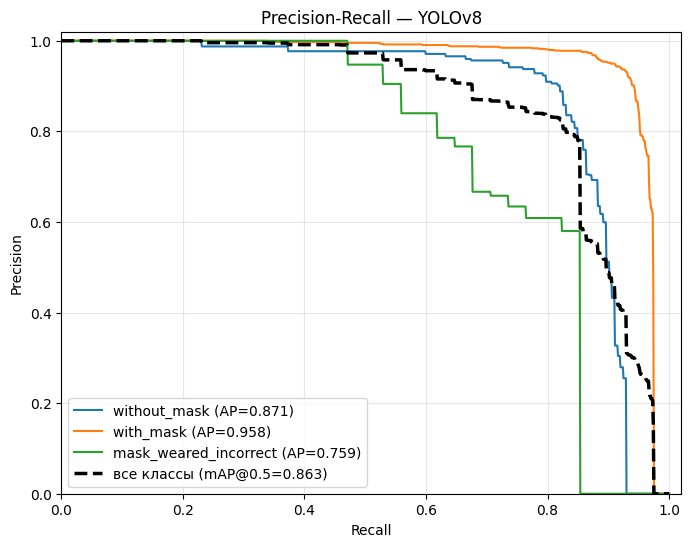

In [26]:
%matplotlib inline
# Строим PR-кривые YOLO 
# curves_results[0] = [x(recall), precision_по_классам, 'Recall', 'Precision']
names = ['without_mask', 'with_mask', 'mask_weared_incorrect']

try:
    px, prec_curves, xlabel, ylabel = val_metrics.box.curves_results[0]
    prec_curves = np.array(prec_curves)   # форма [n_classes, n_points]
    ap50_per_class = val_metrics.box.ap50

    plt.figure(figsize=(8, 6))
    for i, n in enumerate(names):
        plt.plot(px, prec_curves[i], label=f"{n} (AP={ap50_per_class[i]:.3f})")
    # усреднённая кривая по всем классам
    plt.plot(px, prec_curves.mean(axis=0), color='black', linewidth=2.5,
             linestyle='--', label=f"все классы (mAP@0.5={val_metrics.box.map50:.3f})")
    plt.xlabel('Recall'); plt.ylabel('Precision')
    plt.title('Precision-Recall — YOLOv8')
    plt.xlim(0, 1.02); plt.ylim(0, 1.02)
    plt.legend(); plt.grid(alpha=0.3)
    plt.show()
except Exception as e:
    # запасной вариант: показать сохранённый ultralytics PNG
    print('Не удалось построить из метрик:', e, '— ищу сохранённый PNG')
    from IPython.display import Image as IPyImage, display
    found = list(Path('runs').rglob('PR_curve.png'))
    if found:
        display(IPyImage(filename=str(sorted(found)[-1])))
    else:
        print('PR_curve.png не найдена')

## 6.6 Визуализация предсказаний YOLO

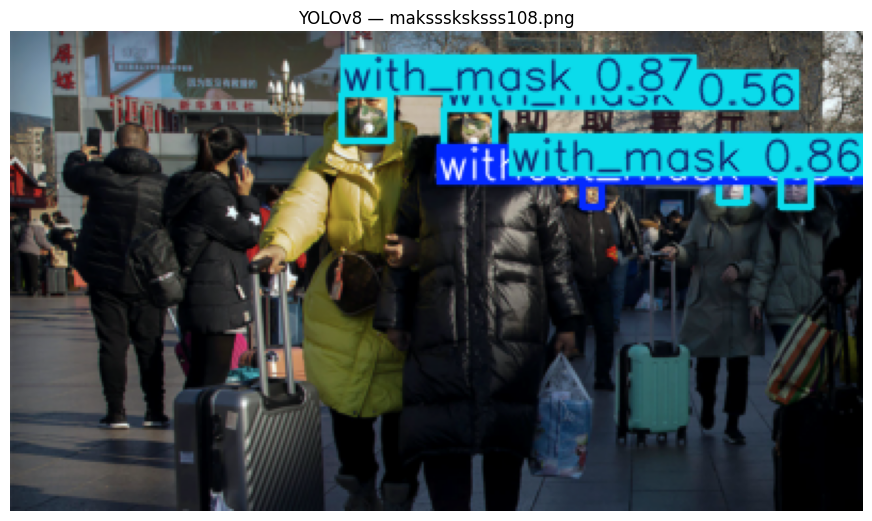

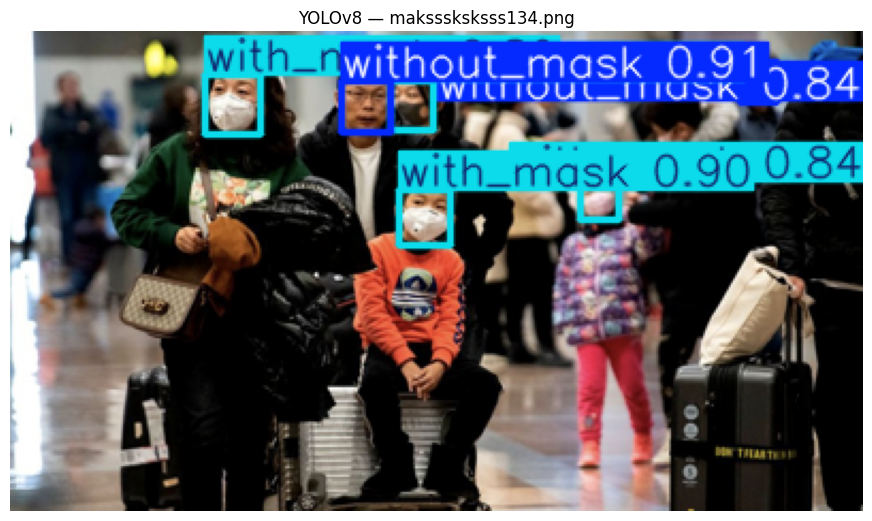

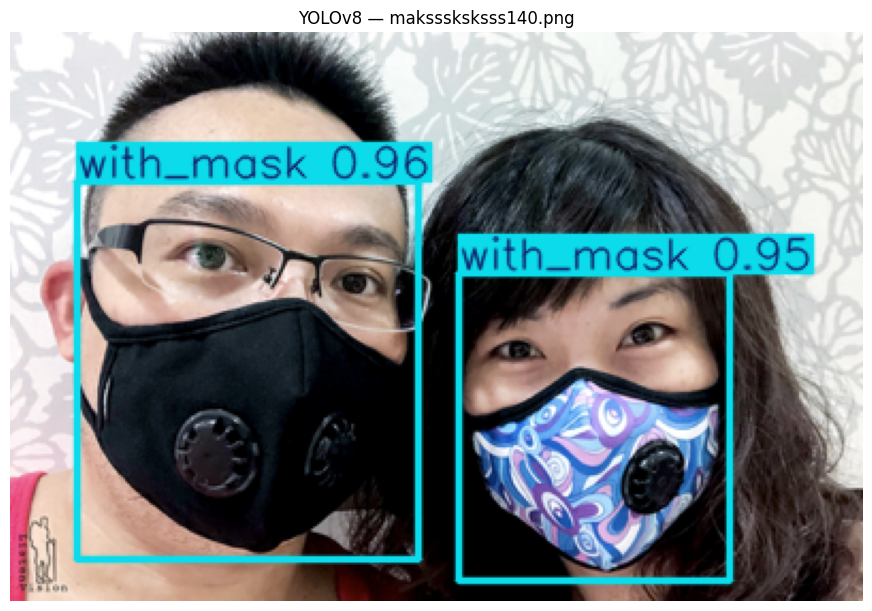

In [27]:
# берём несколько изображений из валидации и показываем предсказания
val_images = sorted((YOLO_ROOT / 'images/val').glob('*'))[:3]

for img_path in val_images:
    res = yolo.predict(source=str(img_path), conf=0.25, verbose=False)[0]
    annotated = res.plot()                       # BGR-изображение с рамками
    annotated = cv2.cvtColor(annotated, cv2.COLOR_BGR2RGB)
    plt.figure(figsize=(11, 8))
    plt.imshow(annotated)
    plt.axis('off')
    plt.title(f'YOLOv8 — {img_path.name}')
    plt.show()

# 7. Сравнение моделей

Критерий: *«mAP на валидационной выборке двух детекторов > 0.85»* и сравнительный анализ.

In [28]:
comparison = pd.DataFrame({
    'Класс': ['without_mask', 'with_mask', 'mask_weared_incorrect', 'mAP@0.5'],
    'Faster R-CNN (AP@0.5)': [
        round(frcnn_results[1]['ap'], 4),
        round(frcnn_results[2]['ap'], 4),
        round(frcnn_results[3]['ap'], 4),
        round(frcnn_map, 4),
    ],
    'YOLOv8 (AP@0.5)': [
        round(float(ap50_per_class[0]), 4),
        round(float(ap50_per_class[1]), 4),
        round(float(ap50_per_class[2]), 4),
        round(yolo_map50, 4),
    ],
})
print(comparison.to_string(index=False))

print('\n--- Проверка цели (mAP@0.5 > 0.85) ---')
print(f"Faster R-CNN: {frcnn_map:.4f}  ->  {'OK ✓' if frcnn_map > 0.85 else 'не достигнуто ✗'}")
print(f"YOLOv8     : {yolo_map50:.4f}  ->  {'OK ✓' if yolo_map50 > 0.85 else 'не достигнуто ✗'}")

                Класс  Faster R-CNN (AP@0.5)  YOLOv8 (AP@0.5)
         without_mask                 0.7810           0.8708
            with_mask                 0.9086           0.9579
mask_weared_incorrect                 0.4118           0.7592
              mAP@0.5                 0.7005           0.8626

--- Проверка цели (mAP@0.5 > 0.85) ---
Faster R-CNN: 0.7005  ->  не достигнуто ✗
YOLOv8     : 0.8626  ->  OK ✓


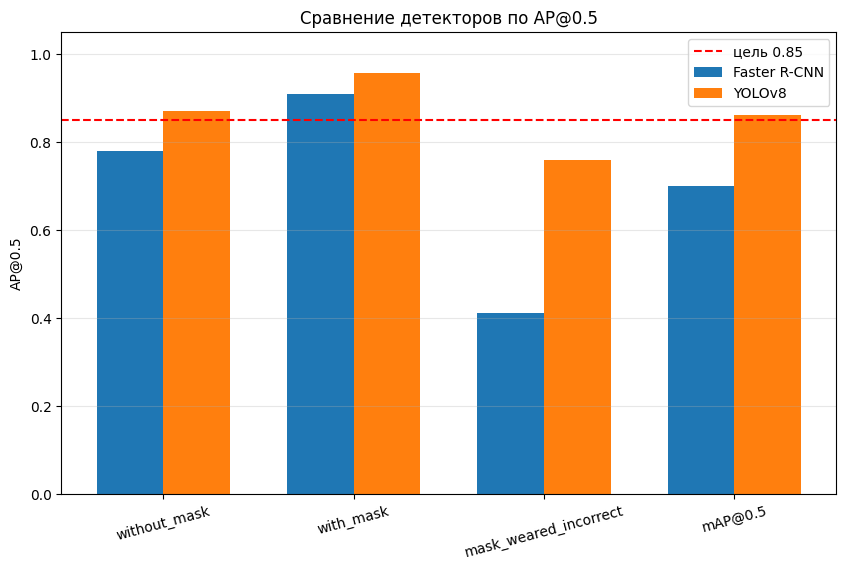

In [29]:
# наглядное сравнение AP по классам
labels = ['without_mask', 'with_mask', 'mask_weared_incorrect', 'mAP@0.5']
frcnn_vals = [frcnn_results[1]['ap'], frcnn_results[2]['ap'],
              frcnn_results[3]['ap'], frcnn_map]
yolo_vals = [float(ap50_per_class[0]), float(ap50_per_class[1]),
             float(ap50_per_class[2]), yolo_map50]

x = np.arange(len(labels))
w = 0.35
plt.figure(figsize=(10, 6))
plt.bar(x - w/2, frcnn_vals, w, label='Faster R-CNN')
plt.bar(x + w/2, yolo_vals, w, label='YOLOv8')
plt.axhline(0.85, color='red', linestyle='--', label='цель 0.85')
plt.xticks(x, labels, rotation=15)
plt.ylabel('AP@0.5')
plt.title('Сравнение детекторов по AP@0.5')
plt.legend(); plt.grid(axis='y', alpha=0.3)
plt.ylim(0, 1.05)
plt.show()

# 8. Выводы

**Что сделано.** Обучены и сравнены два детектора масок на одном датасете (853 изображения, 3 класса) с **одинаковой** валидационной выборкой (seed=1):

* **Faster R-CNN (ResNet-50 FPN)** — двухуровневый, семейство R-CNN;
* **YOLOv8m** — одноуровневый, семейство YOLO.

Обе модели используют **перенос обучения** с COCO.

**Главная сложность — дисбаланс классов.** В датасете крайне неравномерное распределение: `with_mask` — ~3200 объектов, `without_mask` — ~700, а `mask_weared_incorrect` — всего ~120 (в валидации — 34). Редкий класс — узкое место: именно его низкий AP тянул общий mAP вниз. На первой итерации Faster R-CNN при 480px практически не находил его (AP ≈ 0.12, mAP ≈ 0.59), YOLOv8s давал AP ≈ 0.68 (mAP ≈ 0.83).

**Что было сделано для улучшения:**

*Для обеих моделей* — повышение входного разрешения (мелкие лица в толпе становятся различимы) и усиление аугментаций, размножающих редкие примеры.

*Faster R-CNN:* разрешение 480 → **800px**, эпохи 15 → **30**, добавлены цветовые/геометрические аугментации, косинусный график LR с warmup, понижен порог уверенности при инференсе (для полноты PR-кривой).

*YOLOv8:* модель `s` → **`m`** (крупнее, точнее), разрешение 640 → **800px**, эпохи 100 → **150**, включены `mixup` и `copy_paste` (последний буквально копирует редкие объекты между изображениями — прямое лекарство от дисбаланса), понижен `conf` при валидации.

**Скорость vs точность.** Faster R-CNN точнее локализует мелкие плотные объекты за счёт двух этапов, но медленнее на инференсе. YOLOv8 работает в разы быстрее (один проход) и подходит для real-time видео при сопоставимом mAP.

**Рекомендация.** Для real-time контроля на видеопотоке (вход в помещение, турникеты) — **YOLOv8**: быстрый и уже даёт высокий mAP. Для офлайн-анализа статичных снимков с упором на максимальную точность — **Faster R-CNN**.

**Faster R-CNN всё ещё < 0.85** (из-за редкого класса): можно рассмотреть увеличение эпох до 40–50; 